# 2.0_performance_comparisons visualizes patient embeddings for GSPA and comparisons and calculates classification AUROC for each pt feature calculation

In [1]:
import os, phate, scprep, scanpy, matplotlib
import numpy as np
import pandas as pd
import sklearn, scipy
from sklearn import model_selection, linear_model, metrics, preprocessing
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
data = scanpy.read_h5ad('/data/lab/datasets/cpi_melanoma/processed_data.h5ad')
patient_label = data.obs[['patient','response']].drop_duplicates().set_index('patient').to_dict()['response']
patient_label = dict(zip(patient_label.keys(), (np.array(list(patient_label.values())) == 'R').astype(int)))
y = np.array([patient_label[x] for x in np.unique(data.obs['patient'])])

In [3]:
datasets = {}
for pt_features in os.listdir('results'):
    pt_features_name = pt_features.split('.npy')[0]
    datasets[pt_features_name] = np.load(f'results/{pt_features}').reshape(48,-1)

In [7]:
colors = {'mustard': '#E1AD01', 'berry': '#AC2F3D', 'teal': '#216E76', 'purple':'#502A4F', 
          'forest': '#065535', 'light forest': '#519167',
          'light yellow': '#E3BC81', 'light berry': '#c7505d', 'light gray': 'lightgray',
          'light teal': '#81ABA1', 'light purple': '#95636E', 'black': '#000000'}

/home/aarthivenkat/.local/lib/python3.8/site-packages/graphtools/graphs.py:122: UserWarning: Building a kNNGraph on data of shape (48, 61820) is expensive. Consider setting n_pca.
  warnings.warn(
/home/aarthivenkat/.local/lib/python3.8/site-packages/graphtools/graphs.py:122: UserWarning: Building a kNNGraph on data of shape (48, 12364) is expensive. Consider setting n_pca.
  warnings.warn(


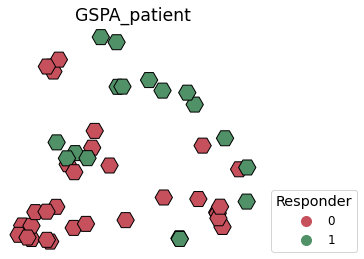

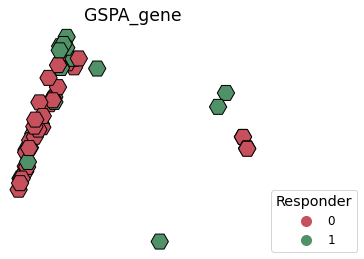

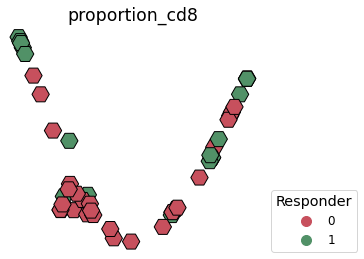

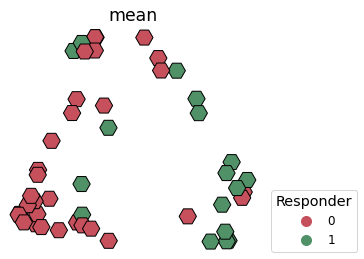

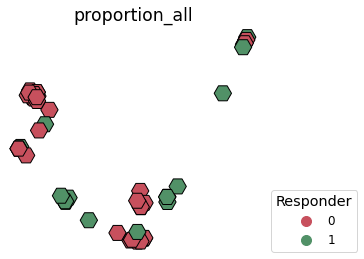

In [14]:
for name, pt_features in datasets.items():
    fig, ax = plt.subplots(figsize=(5.5, 4))
    data_phate = phate.PHATE(verbose=False, random_state=42).fit_transform(pt_features)
    scprep.plot.scatter2d(data_phate, ticks=None, c=y, label_prefix='Patient PHATE', title=name,
                          cmap={0: colors['light berry'], 1: colors['light forest']}, s=300,
                          legend_title='Responder', legend_loc=(1.05,0),
                          dpi=200, marker='H', edgecolor='black', ax=ax)
    plt.tight_layout()
    plt.axis('off')
    plt.savefig(f'figures/{name}_patient_embedding.png', dpi=200)
    

In [6]:
res = {}
for name, dataset in datasets.items():
    auroc = []
    for i in range(100):
        X_train, X_test, y_train, y_test = model_selection.train_test_split(dataset,y,
                                                                            test_size=0.5, random_state=i)
        clf = linear_model.RidgeClassifier()
        clf.fit(X_train, y_train)
        y_pred = clf.decision_function(X_test)
        fpr, tpr, _ = metrics.roc_curve(y_test, y_pred)
        auroc.append(metrics.roc_auc_score(y_test, y_pred))
        res[name] = auroc

In [7]:
df = pd.DataFrame(index=['method', 'response_AUROC'], 
                  data=[np.repeat(list(res.keys()), 100), [x for sublist in list(res.values()) for x in sublist]]).T
df = df.groupby('method').mean()

In [8]:
df

,response_AUROC
method,
GSPA_gene,0.863763
GSPA_patient,0.848356
mean,0.845018
proportion_all,0.822943
proportion_cd8,0.799365


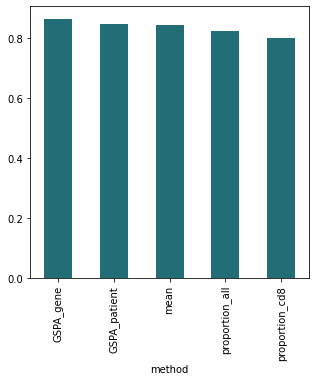

In [10]:
df['response_AUROC'].plot(kind='bar', figsize=(5,5), color=colors['teal'])
plt.savefig('figures/response_AUROC.png', dpi=200)